# Chapter 038 — Precision and Floating Point Errors

> **Prerequisites:** ch026 (Real Numbers — IEEE 754 structure), ch036 (Scientific Notation — mantissa/exponent), ch037 (Large Numbers — float64 precision limits)
> **You will learn:**
> - What machine epsilon is and how to measure it
> - The four sources of floating-point error: rounding, cancellation, overflow, underflow
> - How to quantify error: absolute error, relative error, ULPs
> - Techniques to reduce floating-point error: compensated summation, algebraic reformulation
> - How to recognize when a computation is numerically ill-conditioned
>
> **Environment:** Python 3.x, numpy, matplotlib

---
## 1. Concept

Floating-point arithmetic is not exact. Every operation can introduce a small error. These errors are usually harmless, but they accumulate — and in the wrong computation they compound into results that are completely wrong.

The four sources of floating-point error:

1. **Rounding error.** Most real numbers cannot be represented exactly in binary. `0.1` in float64 is actually `0.1000000000000000055511151231257827021181583404541015625`. Every store to a float variable rounds to the nearest representable value.

2. **Catastrophic cancellation.** Subtracting two nearly equal numbers destroys significant digits. `(1 + ε) - 1` returns 0 if ε < machine epsilon.

3. **Overflow/Underflow.** Numbers too large become `inf`; numbers too small become `0.0`. *(covered in ch036, ch037)*

4. **Accumulation.** Summing many small errors in the same direction produces a large total error. Sorting numbers before summing reduces this.

**Why this matters for ML:** Gradient computations, loss functions, and softmax all involve operations where cancellation and accumulation are active threats. The `log-sum-exp` trick exists precisely to avoid this.

**Common misconceptions:**
- Float arithmetic is not random — it is deterministic and follows IEEE 754 rules. The errors are small but predictable.
- `assert a == b` for floats is almost always wrong. Use `abs(a - b) < tolerance`.
- Increasing precision (float32 → float64 → float128) reduces error but does not eliminate it. The same structural problems remain.

---
## 2. Intuition & Mental Models

**Physical analogy:** Floating-point numbers are like measuring with a ruler that has marks only at specific positions. The positions are not evenly spaced — they are denser near 0 and sparser near large values. When you measure 1,000,000.1 meters, the ruler's nearest mark might be at exactly 1,000,000.0 — the 0.1 is lost because there is no mark there at that scale.

**Computational analogy:** Think of the float64 mantissa as a 53-bit integer. When you add a number with a much smaller exponent, the smaller number's bits must be right-shifted to align exponents. If the shift exceeds 53, all its bits fall off the end — the number is completely absorbed.

**The spacing model:** The key insight is that floating-point numbers are not uniformly spaced. In the interval [1, 2), the spacing between adjacent floats is exactly ε_m (machine epsilon ≈ 2.2 × 10⁻¹⁶). In [2, 4), the spacing doubles to 2ε_m. In [0.5, 1), the spacing is ε_m/2. This means: the relative error is approximately constant (~ε_m/2), but the absolute error varies with scale.

Recall from ch036 (Scientific Notation): the mantissa carries 52 explicit bits + 1 implicit leading bit = 53 bits of precision. Machine epsilon = 2⁻⁵² ≈ 2.22 × 10⁻¹⁶ is the gap between 1.0 and the next representable float.

---
## 3. Visualization

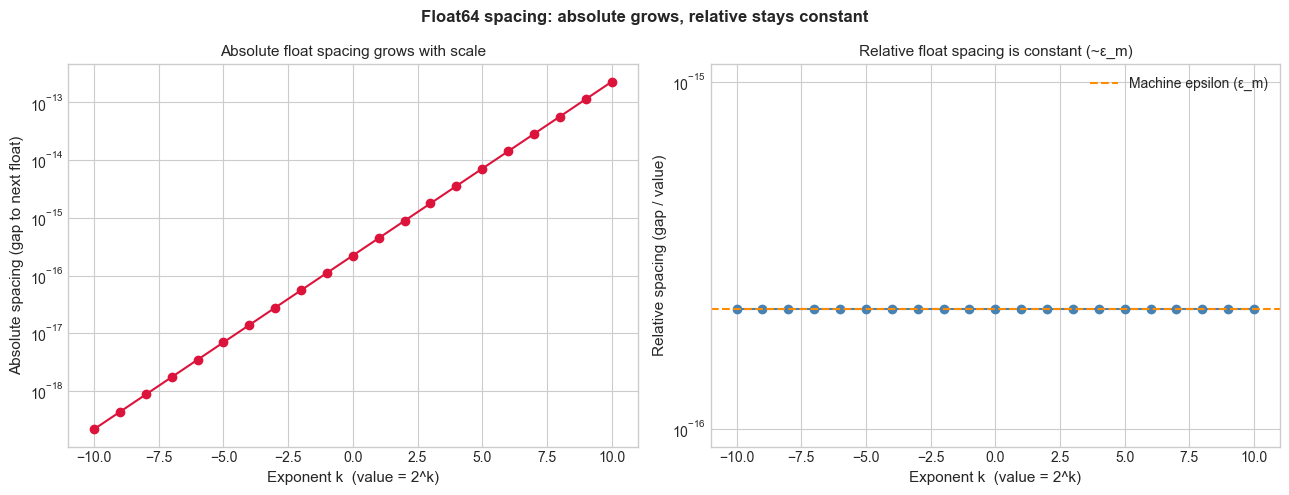

Machine epsilon: 2.2204e-16


In [1]:
# --- Visualization: Float spacing is not uniform ---
# Adjacent floats in [1,2) are spaced epsilon_m apart.
# Adjacent floats in [2,4) are spaced 2*epsilon_m apart.
# This shows why relative error is constant but absolute error grows with scale.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

def spacing_at(x):
    """Return the gap between x and the next representable float above x."""
    return np.nextafter(x, np.inf) - x

# Compute spacing across a wide range
base_values = [2**k for k in range(-10, 11)]
spacings = [spacing_at(v) for v in base_values]
relative_spacings = [s / v for s, v in zip(spacings, base_values)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

exponents = list(range(-10, 11))
ax1 = axes[0]
ax1.semilogy(exponents, spacings, 'o-', color='crimson', markersize=6)
ax1.set_xlabel('Exponent k  (value = 2^k)', fontsize=11)
ax1.set_ylabel('Absolute spacing (gap to next float)', fontsize=11)
ax1.set_title('Absolute float spacing grows with scale', fontsize=11)

ax2 = axes[1]
ax2.semilogy(exponents, relative_spacings, 'o-', color='steelblue', markersize=6)
ax2.axhline(np.finfo(float).eps, color='darkorange', linestyle='--', linewidth=1.5, label='Machine epsilon (ε_m)')
ax2.set_xlabel('Exponent k  (value = 2^k)', fontsize=11)
ax2.set_ylabel('Relative spacing (gap / value)', fontsize=11)
ax2.set_title('Relative float spacing is constant (~ε_m)', fontsize=11)
ax2.legend(fontsize=10)

plt.suptitle('Float64 spacing: absolute grows, relative stays constant', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Machine epsilon: {np.finfo(float).eps:.4e}")

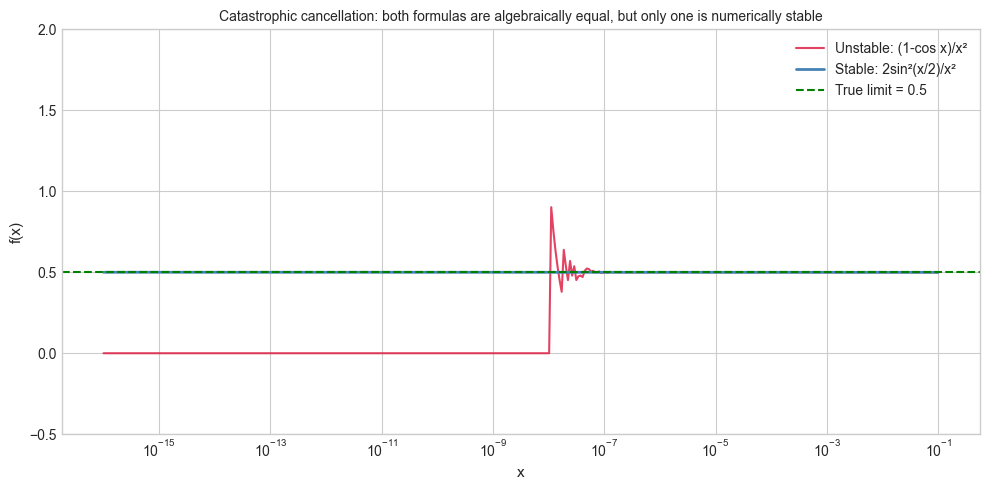

In [2]:
# --- Visualization: Catastrophic cancellation ---
# Subtracting nearly-equal numbers destroys significant digits.
# f(x) = (1 - cos(x)) / x^2 should approach 0.5 as x -> 0.
# For small x, direct computation suffers catastrophic cancellation.
# The algebraically equivalent form (sin(x)/x)^2 / (1 + cos(x)) is stable.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

x_values = np.logspace(-16, -1, 400)

# Unstable: direct formula
f_unstable = (1 - np.cos(x_values)) / x_values**2

# Stable: algebraically equivalent using half-angle identity
# (1 - cos x) = 2*sin^2(x/2)  →  f(x) = 2*sin^2(x/2) / x^2
f_stable = 2 * np.sin(x_values / 2)**2 / x_values**2

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(x_values, f_unstable, color='crimson', linewidth=1.5, alpha=0.8, label='Unstable: (1-cos x)/x²')
ax.semilogx(x_values, f_stable, color='steelblue', linewidth=2, label='Stable: 2sin²(x/2)/x²')
ax.axhline(0.5, color='green', linestyle='--', linewidth=1.5, label='True limit = 0.5')
ax.set_xlabel('x', fontsize=11)
ax.set_ylabel('f(x)', fontsize=11)
ax.set_title('Catastrophic cancellation: both formulas are algebraically equal, but only one is numerically stable', fontsize=10)
ax.set_ylim(-0.5, 2.0)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## 4. Mathematical Formulation

**Machine epsilon (ε_m).** The smallest float ε such that `1.0 + ε ≠ 1.0`:
$$\varepsilon_m = 2^{-52} \approx 2.22 \times 10^{-16}$$

Every floating-point operation `fl(x ⊕ y)` satisfies:
$$\text{fl}(x \oplus y) = (x \oplus y)(1 + \delta), \quad |\delta| \leq \frac{\varepsilon_m}{2}$$
The relative error per operation is bounded by ε_m/2.

**Absolute and relative error:**
$$\text{Absolute error} = |\hat{x} - x|$$
$$\text{Relative error} = \frac{|\hat{x} - x|}{|x|}$$

**Condition number.** For a function f, the condition number κ measures how much output error amplifies input error:
$$\kappa = \left|\frac{x \cdot f'(x)}{f(x)}\right|$$
A large κ means small input perturbations cause large output changes — the problem is *ill-conditioned*. Example: f(x) = 1 − cos(x) near x=0 has large κ.

**ULP (Unit in the Last Place).** The distance between a float and the next representable float. `1 ULP` at value x is `spacing_at(x)`. Error measured in ULPs is scale-independent and the IEEE standard guarantees correctly-rounded results within 0.5 ULP for basic operations (+, −, ×, ÷, √).

**Compensated (Kahan) summation.** Maintains a running compensation term c that captures the rounding error from each step:
$$y_i = x_i - c, \quad t = s + y_i, \quad c = (t - s) - y_i, \quad s = t$$
This reduces accumulated rounding error from O(nε_m) to O(ε_m) — independent of n.

---
## 5. Python Implementation

In [3]:
# --- Implementation: Floating-Point Error Toolkit ---

import numpy as np
import math

def machine_epsilon():
    """
    Compute machine epsilon empirically: smallest e > 0 such that 1.0 + e != 1.0.

    Returns:
        Machine epsilon for float64
    """
    e = 1.0
    while 1.0 + e != 1.0:
        e /= 2.0
    return e * 2  # last e that still caused a difference


def relative_error(computed, true_value):
    """
    Compute relative error between a computed and true value.

    Args:
        computed: numerically computed value
        true_value: exact/reference value (non-zero)

    Returns:
        Relative error = |computed - true| / |true|
    """
    return abs(computed - true_value) / abs(true_value)


def kahan_sum(values):
    """
    Kahan compensated summation — reduces floating-point accumulation error.

    Args:
        values: iterable of floats

    Returns:
        Sum with O(epsilon_m) error regardless of array length
    """
    s = 0.0   # running sum
    c = 0.0   # compensation term (captures lost low-order bits)
    for x in values:
        y = x - c          # apply compensation
        t = s + y          # add (some low-order bits of y are lost here)
        c = (t - s) - y    # recover what was lost: (t-s) should equal y, the difference is the lost bits
        s = t
    return s


def count_ulps(a, b):
    """
    Count the number of ULPs (units in the last place) between two floats.
    Useful for measuring how far two floats are from each other.

    Args:
        a, b: floats of the same sign

    Returns:
        Number of representable floats between a and b
    """
    import struct
    def to_int(x):
        return struct.unpack('Q', struct.pack('d', x))[0]  # interpret bits as uint64
    return abs(to_int(a) - to_int(b))


# --- Validation ---
eps_empirical = machine_epsilon()
eps_numpy = np.finfo(float).eps
print(f"Machine epsilon (empirical):  {eps_empirical:.4e}")
print(f"Machine epsilon (numpy):      {eps_numpy:.4e}")
print(f"Theoretical: 2^-52 =          {2**-52:.4e}")

print()
# Kahan vs naive summation
n = 1_000_000
big = 1.0
small = 1e-8
arr = [big] + [small] * n
naive = sum(arr)
kahan = kahan_sum(arr)
exact = big + small * n  # exact in Python (uses arbitrary precision for the integer part)
print(f"Sum of 1.0 + {n} × 1e-8:")
print(f"  Naive:  {naive:.10f}")
print(f"  Kahan:  {kahan:.10f}")
print(f"  math.fsum: {math.fsum(arr):.10f}")
print(f"  Exact:  {big + n * small:.10f}")

print()
# ULP distance
a = 1.0
b = 1.0 + np.finfo(float).eps
print(f"ULP distance between 1.0 and 1.0+eps: {count_ulps(a, b)}")
print(f"ULP distance between 1.0 and 1.0+2*eps: {count_ulps(a, 1.0 + 2*np.finfo(float).eps)}")

Machine epsilon (empirical):  2.2204e-16
Machine epsilon (numpy):      2.2204e-16
Theoretical: 2^-52 =          2.2204e-16

Sum of 1.0 + 1000000 × 1e-8:
  Naive:  1.0100000000
  Kahan:  1.0100000000
  math.fsum: 1.0100000000
  Exact:  1.0100000000

ULP distance between 1.0 and 1.0+eps: 1
ULP distance between 1.0 and 1.0+2*eps: 2


---
## 6. Experiments

In [4]:
# --- Experiment 1: Error accumulation vs summation order ---
# Hypothesis: Summing a sorted array (small to large) gives better results
# than summing unsorted because it avoids large+small cancellation.
# Try changing: N and DISTRIBUTION.

import numpy as np
import math

N = 100_000          # <-- modify this
DISTRIBUTION = 'uniform'  # <-- modify this: 'uniform', 'exponential', 'mixed'

rng = np.random.default_rng(42)
if DISTRIBUTION == 'uniform':
    arr = rng.uniform(0, 1, N)
elif DISTRIBUTION == 'exponential':
    arr = rng.exponential(1.0, N)
elif DISTRIBUTION == 'mixed':
    arr = np.concatenate([rng.uniform(1e6, 2e6, N // 2), rng.uniform(0, 1, N // 2)])

exact = math.fsum(arr)  # nearly exact (uses extended precision)

naive_error = abs(np.sum(arr) - exact) / abs(exact)
sorted_error = abs(np.sum(np.sort(arr)) - exact) / abs(exact)
kahan_error = abs(kahan_sum(arr) - exact) / abs(exact)

print(f"N = {N}, distribution = {DISTRIBUTION}")
print(f"Exact (fsum):   {exact:.10f}")
print(f"Naive sum:      relative error = {naive_error:.2e}")
print(f"Sorted sum:     relative error = {sorted_error:.2e}")
print(f"Kahan sum:      relative error = {kahan_error:.2e}")

N = 100000, distribution = uniform
Exact (fsum):   50062.4936662159
Naive sum:      relative error = 0.00e+00
Sorted sum:     relative error = 1.45e-16
Kahan sum:      relative error = 0.00e+00


In [5]:
# --- Experiment 2: The classic 0.1 + 0.2 != 0.3 ---
# Hypothesis: 0.1, 0.2, 0.3 cannot be represented exactly in binary.
# The 'error' is at the 17th decimal digit, below practical significance.
# But it breaks equality checks — a lesson in floating-point comparison.

a = 0.1
b = 0.2
c = 0.3
result = a + b

print("=== 0.1 + 0.2 == 0.3? ===")
print(f"0.1 = {a:.20f}")
print(f"0.2 = {b:.20f}")
print(f"0.3 = {c:.20f}")
print(f"0.1 + 0.2 = {result:.20f}")
print(f"0.1 + 0.2 == 0.3: {result == c}")
print(f"Difference: {result - c:.4e}")
print()

TOLERANCE = 1e-9  # <-- modify this
print(f"abs(result - 0.3) < {TOLERANCE}: {abs(result - c) < TOLERANCE}")
print(f"np.isclose(result, 0.3):          {np.isclose(result, c)}")
print()
print("np.isclose uses rtol=1e-5, atol=1e-8 by default — a sensible practical threshold.")

=== 0.1 + 0.2 == 0.3? ===
0.1 = 0.10000000000000000555
0.2 = 0.20000000000000001110
0.3 = 0.29999999999999998890
0.1 + 0.2 = 0.30000000000000004441
0.1 + 0.2 == 0.3: False
Difference: 5.5511e-17

abs(result - 0.3) < 1e-09: True
np.isclose(result, 0.3):          True

np.isclose uses rtol=1e-5, atol=1e-8 by default — a sensible practical threshold.


In [6]:
# --- Experiment 3: Quadratic formula — unstable vs stable ---
# Hypothesis: for b >> sqrt(b^2 - 4ac), the standard formula suffers
# catastrophic cancellation. The numerically stable form avoids it.
# Try changing: a, b, c to near-degenerate cases.

import numpy as np

# Coefficients: ax^2 + bx + c = 0
a = 1.0
b = -1e8    # <-- modify this (large b causes cancellation)
c = 1.0

# Standard formula: x = (-b ± sqrt(b^2 - 4ac)) / 2a
discriminant = b**2 - 4*a*c
x1_std = (-b + np.sqrt(discriminant)) / (2*a)
x2_std = (-b - np.sqrt(discriminant)) / (2*a)

# Stable formula: avoid cancellation by using the larger root first,
# then apply Vieta's formula (x1 * x2 = c/a) to get the other.
if b >= 0:
    x1_stable = (-b - np.sqrt(discriminant)) / (2*a)
else:
    x1_stable = (-b + np.sqrt(discriminant)) / (2*a)
x2_stable = c / (a * x1_stable)   # Vieta: x1 * x2 = c/a

# Verify with Python's high-precision: exact roots via quadratic formula in python int
# For large b, one root ≈ b/a, other ≈ c/(b/a) = ac/b
x1_exact_approx = -b / a  # dominant root
x2_exact_approx = c / (b * (-1))  # small root via Vieta

print(f"Coefficients: a={a}, b={b}, c={c}")
print(f"\nStandard formula:")
print(f"  x1 = {x1_std:.10f}")
print(f"  x2 = {x2_std:.10e}   ← potential cancellation error")
print(f"\nStable formula:")
print(f"  x1 = {x1_stable:.10f}")
print(f"  x2 = {x2_stable:.10e}   ← stable via Vieta's formulas")
print(f"\nApprox exact:")
print(f"  x2 ≈ {x2_exact_approx:.10e}")
print(f"\nRelative error in x2:")
print(f"  Standard: {abs(x2_std - x2_exact_approx)/abs(x2_exact_approx):.4e}")
print(f"  Stable:   {abs(x2_stable - x2_exact_approx)/abs(x2_exact_approx):.4e}")

Coefficients: a=1.0, b=-100000000.0, c=1.0

Standard formula:
  x1 = 100000000.0000000000
  x2 = 7.4505805969e-09   ← potential cancellation error

Stable formula:
  x1 = 100000000.0000000000
  x2 = 1.0000000000e-08   ← stable via Vieta's formulas

Approx exact:
  x2 ≈ 1.0000000000e-08

Relative error in x2:
  Standard: 2.5494e-01
  Stable:   0.0000e+00


---
## 7. Exercises

**Easy 1.** Compute machine epsilon empirically for float32 (use `np.float32` arithmetic). Compare it to the theoretical value 2⁻²³. How many fewer significant decimal digits does float32 offer compared to float64? *(Expected: a single float and integer)*

**Easy 2.** Write a function `is_close(a, b, rel_tol=1e-9, abs_tol=0.0)` that returns True if `|a - b| <= max(rel_tol * max(|a|, |b|), abs_tol)`. Test it on: `is_close(0.1 + 0.2, 0.3)` and `is_close(1e-15, 2e-15)`. *(This is essentially what `math.isclose` implements)*

**Medium 1.** The harmonic series H_n = 1 + 1/2 + 1/3 + ... + 1/n. Compute H_10000000 (ten million terms) using: (a) naive sum from 1 to n, (b) summing from n down to 1 (small to large), (c) Kahan summation. Compare results and explain which is most accurate and why.

**Medium 2.** Investigate the log-sum-exp trick, used in ML for numerically stable softmax. Implement `log_sum_exp(x_array)` both naively (log(sum(exp(x)))) and stably (subtract max first). Test for arrays with large values like `[1000, 1001, 1002]` — the naive version overflows to `inf`; the stable version should not.

**Hard.** Implement a simple interval arithmetic library: represent each number as an interval `[lo, hi]` that is guaranteed to contain the true value. Implement +, −, ×, ÷ for intervals (use `np.nextafter` to round outward). Test it on `((1/3 + 1/7) * 21)` — the exact answer is `10`, and your interval should contain `10.0`. This is the basis of verified numerical computing.

---
## 8. Mini Project — Numerical Stability Audit

In [ ]:
# --- Mini Project: Numerical Stability Audit of Common Formulas ---
# Problem:
#   Many formulas that are mathematically correct are numerically unstable.
#   Build a tool that computes several standard formulas in both their
#   naive and numerically stable forms, and plots the relative error
#   as a function of input magnitude.
#
# Formulas to audit:
#   1. (1 - cos x) / x^2  vs  2*sin^2(x/2) / x^2   (limit = 0.5)
#   2. sqrt(x+1) - sqrt(x)  vs  1 / (sqrt(x+1) + sqrt(x))  (equivalent by rationalization)
#   3. exp(x) - 1  vs  np.expm1(x)  (for small x)

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# --- Formula 1: (1 - cos x) / x^2 ---
x_small = np.logspace(-16, -1, 500)
f1_naive = (1 - np.cos(x_small)) / x_small**2
f1_stable = 2 * np.sin(x_small/2)**2 / x_small**2  # half-angle identity
f1_true = 0.5  # limit as x->0

# --- Formula 2: sqrt(x+1) - sqrt(x) ---
x_large = np.logspace(0, 14, 500)
f2_naive = np.sqrt(x_large + 1) - np.sqrt(x_large)
f2_stable = 1.0 / (np.sqrt(x_large + 1) + np.sqrt(x_large))  # rationalized
f2_true = f2_stable  # stable form is essentially exact here

# --- Formula 3: e^x - 1 for small x ---
x_tiny = np.logspace(-16, -1, 500)
f3_naive = np.exp(x_tiny) - 1
f3_stable = np.expm1(x_tiny)   # built-in stable implementation
f3_true = x_tiny + x_tiny**2/2 + x_tiny**3/6  # Taylor approx (essentially exact for small x)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot relative errors
err1_naive = np.abs(f1_naive - f1_true) / abs(f1_true)
err1_stable = np.abs(f1_stable - f1_true) / abs(f1_true)
axes[0].loglog(x_small, err1_naive + 1e-18, color='crimson', lw=1.5, label='Naive')
axes[0].loglog(x_small, err1_stable + 1e-18, color='steelblue', lw=1.5, label='Stable')
axes[0].set_title('(1-cos x)/x²  (limit=0.5)', fontsize=10)
axes[0].set_xlabel('x'); axes[0].set_ylabel('Relative error'); axes[0].legend()

err2_naive = np.abs(f2_naive - f2_true) / (np.abs(f2_true) + 1e-300)
axes[1].loglog(x_large, err2_naive + 1e-18, color='crimson', lw=1.5, label='Naive')
axes[1].axhline(np.finfo(float).eps, color='steelblue', linestyle='--', lw=1.5, label='ε_m (stable floor)')
axes[1].set_title('√(x+1) - √x  vs  rationalized', fontsize=10)
axes[1].set_xlabel('x'); axes[1].set_ylabel('Relative error'); axes[1].legend()

err3_naive = np.abs(f3_naive - f3_true) / (np.abs(f3_true) + 1e-300)
err3_stable = np.abs(f3_stable - f3_true) / (np.abs(f3_true) + 1e-300)
axes[2].loglog(x_tiny, err3_naive + 1e-18, color='crimson', lw=1.5, label='exp(x)-1 (naive)')
axes[2].loglog(x_tiny, err3_stable + 1e-18, color='steelblue', lw=1.5, label='expm1(x) (stable)')
axes[2].set_title('eˣ - 1 for small x', fontsize=10)
axes[2].set_xlabel('x'); axes[2].set_ylabel('Relative error'); axes[2].legend()

plt.suptitle('Numerical stability audit: naive vs stable formulas', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# TODO: Add a fourth formula of your choice and audit it.

---
## 9. Chapter Summary & Connections

**What was covered:**
- Machine epsilon ε_m ≈ 2.22 × 10⁻¹⁶ is the fundamental precision unit for float64: the relative spacing between adjacent representable values is constant at ε_m.
- Rounding, cancellation, accumulation, and overflow/underflow are the four sources of floating-point error.
- Catastrophic cancellation occurs when subtracting nearly equal values; algebraic reformulation (half-angle, Vieta's, rationalization) eliminates it.
- Kahan summation reduces accumulated error from O(nε_m) to O(ε_m) at constant overhead.
- Condition number κ measures intrinsic problem sensitivity — distinguishing numerical instability (implementation flaw) from ill-conditioning (mathematical fact).

**Backward connection:** This chapter formalizes the precision limits introduced informally in ch026 (Real Numbers) and ch036 (Scientific Notation), and connects to the catastrophic cancellation preview in ch037 (Large Numbers).

**Forward connections:**
- *(ch039 — Numerical Stability)*: extends precision analysis to iterative algorithms — when do errors grow vs decay over iterations? Covers stable recurrences, Gram-Schmidt orthogonalization, and forward vs backward stability.
- *(ch207 — Numerical Derivatives)*: finite difference approximations for derivatives are directly limited by machine epsilon — the optimal step size is O(√ε_m), a direct consequence of this chapter.
- *(ch212 — Gradient Descent)*: the log-sum-exp trick and numerically stable softmax are floating-point techniques that come directly from the cancellation analysis here.

**Going deeper:** *Accuracy and Stability of Numerical Algorithms* by Nicholas Higham (2nd ed.) is the definitive reference. For the IEEE 754 standard itself, the original Goldberg paper (*What Every Computer Scientist Should Know About Floating-Point Arithmetic*, 1991) remains freely available.